# Install + Imports

In [1]:
!pip3 install pytest

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip3 install typeguard


Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip3 -q install transformer-lens==1.14.0 einops tqdm

import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import pytest

In [4]:
plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs
colors = plt.cm.plasma(np.linspace(0,1,9))

In [5]:
from transformer_lens import HookedTransformer
torch.set_grad_enabled(False)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

/Users/singh_h/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


device: cpu


# Load Small Open Model

In [6]:
model_name = "gpt2-small"
model = HookedTransformer.from_pretrained(model_name, device=device)
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2-small into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint()
  (blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (ln1): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNormPre(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
      (h

# Build Clean/ Corrupted Task

We will employ a classic `indirect-object identification-style` micro-task (simple yet circuit-like). Consider example:

-- CLEAN: "Alice gave the ball to Bob. Who recieved the ball? BOB"

-- CORRUPTED: (swap names)::--> "Alice gave the ball to Eve. Who recieved the ball? EVE" 

"Circuit" should route info from the earlier sentence to the answer token. 

## Imp TOKENIZATION RULE

For logit comparisons, we need answer tokens to be **single tokens** in the model vocab. 

In [7]:
def single_token_id(s: str) -> int:
    toks = model.to_tokens(s, prepend_bos=False)   # IMPORTANT
    assert toks.shape[1] == 1, f"{s} not single token: {model.to_str_tokens(s, prepend_bos=False)}"
    return int(toks[0, 0])

id_bob = single_token_id(" Bob")
print("Bob token id:", id_bob)


Bob token id: 5811


In [8]:
def is_single_token(s: str) -> bool:
    toks = model.to_tokens(s, prepend_bos=False)
    return toks.shape[1] == 1

candidates = [" Bob", " Tom", " Sam", " Mike", " John", " Jack", " Mary", " Anna", " Max"]
for c in candidates:
    print(c, is_single_token(c), model.to_str_tokens(c, prepend_bos=False))


 Bob True [' Bob']
 Tom True [' Tom']
 Sam True [' Sam']
 Mike True [' Mike']
 John True [' John']
 Jack True [' Jack']
 Mary True [' Mary']
 Anna True [' Anna']
 Max True [' Max']


In [9]:
def single_token_id(s: str) -> int:
    toks = model.to_tokens(s)
    # Expect shape [1,1] for single tokens
    assert toks.shape[1] == 1, f"Input string: {s} is not a single token! tokens={model.to_str_tokens(s)}"
    return int(toks[0,0])

model.to_str_tokens(" Bob")


['<|endoftext|>', ' Bob']

In [10]:
def is_single_token(s: str) -> bool:
    toks = model.to_tokens(s, prepend_bos=False)
    return toks.shape[1] == 1

candidates = [" Bob", " Tom", " Sam", " Mike", " John", " Jack", " Mary", " Anna", " Max"]
for c in candidates:
    print(c, is_single_token(c), model.to_str_tokens(c, prepend_bos=False))


 Bob True [' Bob']
 Tom True [' Tom']
 Sam True [' Sam']
 Mike True [' Mike']
 John True [' John']
 Jack True [' Jack']
 Mary True [' Mary']
 Anna True [' Anna']
 Max True [' Max']


In [11]:
def last_token_id(s: str) -> int:
    toks = model.to_tokens(s)       # allow BOS if present
    return int(toks[0, -1])         # grab last token always


In [13]:
def single_token_id(s: str) -> int:
    toks = model.to_tokens(s, prepend_bos=False)  # critical
    if toks.shape[1] != 1:
        raise AssertionError(
            f"Not a single token: {repr(s)}\n"
            f"Tokens: {model.to_str_tokens(s, prepend_bos=False)}\n"
            f"Token IDs: {toks.tolist()}"
        )
    return int(toks[0, 0])


In [14]:
answer_A = " Bob"
answer_B = " Eve"

print("A tokens:", model.to_str_tokens(answer_A, prepend_bos=False))
print("B tokens:", model.to_str_tokens(answer_B, prepend_bos=False))

id_A = single_token_id(answer_A)
id_B = single_token_id(answer_B)
id_A, id_B


A tokens: [' Bob']
B tokens: [' Eve']


(5811, 12882)

# Define clean/corrupted prompts and a metric

In [15]:
clean_prompt = "Alice gave the ball to Bob. Who received the ball?"
corrupt_prompt = "Alice gave the ball to Eve. Who received the ball?"

def logit_diff(prompt: str) -> float:
    logits = model(prompt)  # [1, seq, vocab]
    last = logits[0, -1]
    return float(last[id_A] - last[id_B])

print("clean logit diff:", logit_diff(clean_prompt))
print("corrupt logit diff:", logit_diff(corrupt_prompt))


clean logit diff: 6.328184127807617
corrupt logit diff: -3.799346923828125


# Activation patching (residual stream): “which layer matters?”

In [16]:
from transformer_lens.hook_points import HookPoint

def get_cache(prompt: str):
    _, cache = model.run_with_cache(prompt)
    return cache

clean_cache = get_cache(clean_prompt)
corrupt_cache = get_cache(corrupt_prompt)

def patched_logit_diff_resid(layer: int) -> float:
    # Hook name for resid_post at layer
    hook_name = f"blocks.{layer}.hook_resid_post"

    def patch_resid(act, hook: HookPoint):
        # act is corrupted resid; replace with clean
        return clean_cache[hook_name]

    logits = model.run_with_hooks(
        corrupt_prompt,
        fwd_hooks=[(hook_name, patch_resid)]
    )
    last = logits[0, -1]
    return float(last[id_A] - last[id_B])

n_layers = model.cfg.n_layers
baseline_clean = logit_diff(clean_prompt)
baseline_corrupt = logit_diff(corrupt_prompt)

patched_scores = []
for layer in tqdm(range(n_layers)):
    patched_scores.append(patched_logit_diff_resid(layer))

patched_scores = np.array(patched_scores)
recovery = (patched_scores - baseline_corrupt) / (baseline_clean - baseline_corrupt + 1e-9)

topk = np.argsort(-recovery)[:5]
print("Top layers by recovery:")
for i in topk:
    print(f"Layer {i:02d} | recovery={recovery[i]:.3f} | patched={patched_scores[i]:.3f}")


100%|██████████| 12/12 [00:00<00:00, 33.37it/s]

Top layers by recovery:
Layer 00 | recovery=1.000 | patched=6.328
Layer 01 | recovery=1.000 | patched=6.328
Layer 02 | recovery=1.000 | patched=6.328
Layer 03 | recovery=1.000 | patched=6.328
Layer 04 | recovery=1.000 | patched=6.328


In [17]:
def patched_logit_diff_resid(layer: int, pos: int = -1) -> float:
    hook_name = f"blocks.{layer}.hook_resid_post"

    clean_act = clean_cache[hook_name]

    def patch_resid(act, hook: HookPoint):
        act = act.clone()
        act[:, pos, :] = clean_act[:, pos, :]
        return act

    logits = model.run_with_hooks(
        corrupt_prompt,
        fwd_hooks=[(hook_name, patch_resid)]
    )
    last = logits[0, -1]
    return float(last[id_A] - last[id_B])


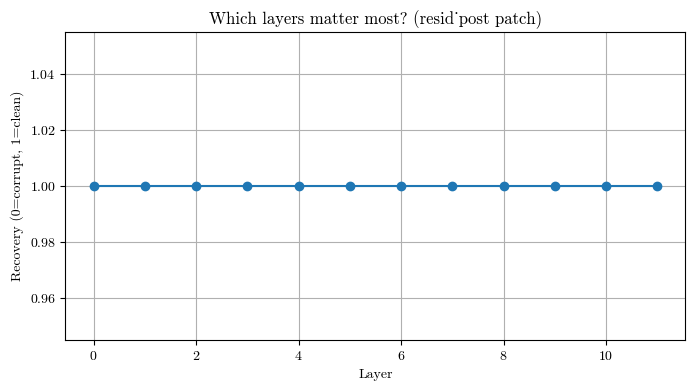

In [18]:
plt.figure(figsize=(8,4))
plt.plot(recovery, marker="o")
plt.xlabel("Layer")
plt.ylabel("Recovery (0=corrupt, 1=clean)")
plt.title("Which layers matter most? (resid_post patch)")
plt.grid(True)
plt.show()


In [19]:
# 1) Are you basically forcing clean logits at every layer?
print("baseline_clean", baseline_clean)
print("baseline_corrupt", baseline_corrupt)
print("patched min/max", patched_scores.min(), patched_scores.max())

# 2) Do the cached activations actually differ across layers?
for l in [0, 1, 5, 10]:
    hn = f"blocks.{l}.hook_resid_post"
    print(l, clean_cache[hn].norm().item())


baseline_clean 6.328184127807617
baseline_corrupt -3.799346923828125
patched min/max 6.328184127807617 6.328184127807617
0 263.5391540527344
1 673.7780151367188
5 3039.4208984375
10 3271.177001953125


In [20]:
print("baseline_clean:", baseline_clean)
print("baseline_corrupt:", baseline_corrupt)
print("patched_scores[:5]:", patched_scores[:5])
print("patched_scores std:", patched_scores.std())


baseline_clean: 6.328184127807617
baseline_corrupt: -3.799346923828125
patched_scores[:5]: [6.32818413 6.32818413 6.32818413 6.32818413 6.32818413]
patched_scores std: 0.0


In [21]:
def patched_logit_diff_head(layer: int, head: int, pos: int = -1) -> float:
    hook_name = f"blocks.{layer}.attn.hook_result"  # shape [batch, seq, n_heads, d_model] in TL

    clean_act = clean_cache[hook_name]

    def patch(act, hook):
        act = act.clone()
        act[:, pos, head, :] = clean_act[:, pos, head, :]
        return act

    logits = model.run_with_hooks(
        corrupt_prompt,
        fwd_hooks=[(hook_name, patch)]
    )
    last = logits[0, -1]
    return float(last[id_A] - last[id_B])


# Head-level circuit tracing (attention output patching)

In [22]:
def patched_logit_diff_head(layer: int, head: int) -> float:
    hook_name = f"blocks.{layer}.attn.hook_z"  # shape [batch, seq, n_heads, d_head]

    def patch_head(z, hook: HookPoint):
        z_clean = clean_cache[hook_name]
        z = z.clone()
        z[:, :, head, :] = z_clean[:, :, head, :]
        return z

    logits = model.run_with_hooks(
        corrupt_prompt,
        fwd_hooks=[(hook_name, patch_head)]
    )
    last = logits[0, -1]
    return float(last[id_A] - last[id_B])

n_heads = model.cfg.n_heads
head_recovery = np.zeros((n_layers, n_heads), dtype=np.float32)

for layer in tqdm(range(n_layers)):
    for head in range(n_heads):
        score = patched_logit_diff_head(layer, head)
        head_recovery[layer, head] = (score - baseline_corrupt) / (baseline_clean - baseline_corrupt + 1e-9)


100%|██████████| 12/12 [00:04<00:00,  2.67it/s]


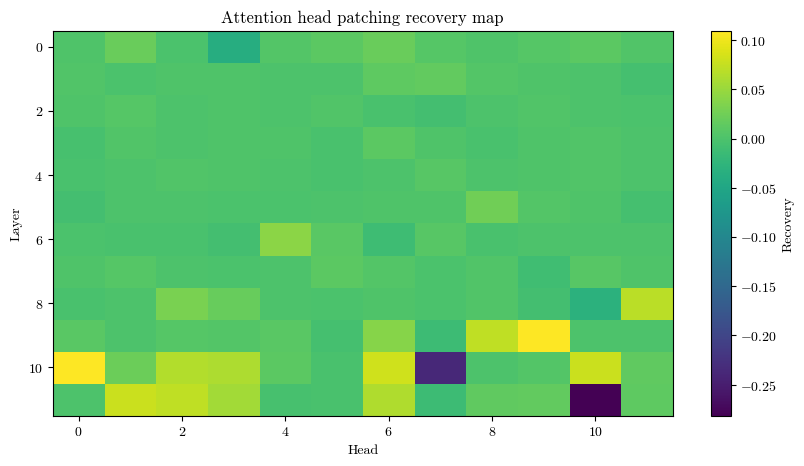

In [23]:
plt.figure(figsize=(10,5))
plt.imshow(head_recovery, aspect="auto")
plt.colorbar(label="Recovery")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.title("Attention head patching recovery map")
plt.show()


In [24]:
flat_idx = np.argsort(-head_recovery.flatten())[:10]
print("Top heads:")
for idx in flat_idx:
    layer = idx // n_heads
    head = idx % n_heads
    print(f"Layer {layer:02d} Head {head:02d} | recovery={head_recovery[layer, head]:.3f}")


Top heads:
Layer 09 Head 09 | recovery=0.110
Layer 10 Head 00 | recovery=0.109
Layer 10 Head 06 | recovery=0.081
Layer 10 Head 10 | recovery=0.079
Layer 11 Head 01 | recovery=0.079
Layer 11 Head 02 | recovery=0.073
Layer 09 Head 08 | recovery=0.072
Layer 08 Head 11 | recovery=0.069
Layer 10 Head 02 | recovery=0.064
Layer 11 Head 06 | recovery=0.063


In [25]:
head_recovery[0,0]

np.float32(0.0018867203)

In [26]:
important = [(int(idx // n_heads), int(idx % n_heads)) for idx in flat_idx[:5]]

def ablate_heads(prompt: str, heads_to_zero):
    hooks = []
    for layer, head in heads_to_zero:
        hook_name = f"blocks.{layer}.attn.hook_z"
        def make_hook(h):
            def ablate(z, hook):
                z = z.clone()
                z[:, :, h, :] = 0
                return z
            return ablate
        hooks.append((hook_name, make_hook(head)))
    logits = model.run_with_hooks(prompt, fwd_hooks=hooks)
    last = logits[0, -1]
    return float(last[id_A] - last[id_B])

print("clean baseline:", baseline_clean)
print("clean after ablation:", ablate_heads(clean_prompt, important))


clean baseline: 6.328184127807617
clean after ablation: 5.382203102111816


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

In [33]:
# --- inputs assumed to exist ---
# head_recovery: shape (n_layers, n_heads)
# flat_idx: 1D iterable of selected heads encoded as layer*n_heads + head
# n_layers, n_heads: ints

flat_idx = np.array(list(flat_idx), dtype=int)
layers = flat_idx // n_heads
heads  = flat_idx % n_heads
vals   = head_recovery[layers, heads]

# Sort by recovery (desc) for nicer plotting + annotations
order = np.argsort(-vals)
layers, heads, vals, flat_idx = layers[order], heads[order], vals[order], flat_idx[order]

topk = min(10, len(vals))  # annotate up to 10
top_layers, top_heads, top_vals = layers[:topk], heads[:topk], vals[:topk]

fig = plt.figure(figsize=(18, 6), constrained_layout=True,dpi=1000)
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1.15, 1.4])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

# --------------------------
# (1) Head index vs recovery, colored by layer
# --------------------------
sc1 = ax1.scatter(
    heads, vals,
    c=layers, cmap="inferno",
    s=35, alpha=0.75, edgecolors="none"
)
ax1.set_title("Selected heads: recovery vs head (colored by layer)")
ax1.set_xlabel("Head")
ax1.set_ylabel("Recovery")
ax1.set_xlim(-0.5, n_heads - 0.5)
ax1.grid(True, alpha=0.25)

cb1 = fig.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label("Layer")

# annotate top-k points
for L, H, R in zip(top_layers, top_heads, top_vals):
    ax1.scatter([H], [R], s=90, facecolors="none", edgecolors="k", linewidths=1.2)
    ax1.annotate(f"L{L}:H{H}\n{R:.3f}", (H, R),
                 textcoords="offset points", xytext=(6, 6), fontsize=8)

# --------------------------
# (2) Layer index vs recovery, colored by head
# --------------------------
sc2 = ax2.scatter(
    layers, vals,
    c=heads, cmap="inferno",
    s=35, alpha=0.75, edgecolors="none"
)
ax2.set_title("Selected heads: recovery vs layer (colored by head)")
ax2.set_xlabel("Layer")
ax2.set_ylabel("Recovery")
ax2.set_xlim(-0.5, n_layers - 0.5)
ax2.grid(True, alpha=0.25)

cb2 = fig.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label("Head")

# annotate top-k points
for L, H, R in zip(top_layers, top_heads, top_vals):
    ax2.scatter([L], [R], s=90, facecolors="none", edgecolors="k", linewidths=1.2)
    ax2.annotate(f"H{H}\n{R:.3f}", (L, R),
                 textcoords="offset points", xytext=(6, 6), fontsize=8)

# --------------------------
# (3) Heatmap view (best for "where are the important heads?")
# We'll show full head_recovery, and overlay selected flat_idx as markers.
# --------------------------
# Robust color scaling so a few outliers don't wash everything out
vmin = np.nanpercentile(head_recovery, 5)
vmax = np.nanpercentile(head_recovery, 95)
norm = colors.Normalize(vmin=vmin, vmax=vmax)

im = ax3.imshow(head_recovery, aspect="auto", origin="lower", norm=norm, cmap=plt.cm.inferno,interpolation='hamming') #lanczos
ax3.set_title("Head recovery heatmap (all layers/heads)")
ax3.set_xlabel("Head")
ax3.set_ylabel("Layer")

# overlay selected heads
ax3.scatter(heads, layers, s=18, facecolors="none", edgecolors="w", linewidths=0.8, alpha=0.9)

# overlay top-k with bigger markers
ax3.scatter(top_heads, top_layers, s=80, facecolors="none", edgecolors="k", linewidths=1.5)

cb3 = fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
cb3.set_label("Recovery")

plt.show()
